In [1]:
import torch 
from torch import nn 
from torch.utils.data import DataLoader, random_split
from torchvision import datasets 
from torchvision.transforms import v2 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [2]:
def set_seed(): 
    SEED_VALUE = 42
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE)
        torch.cuda.manual_seed_all(SEED_VALUE)
set_seed()

# 1. Exploratory Data Analysis
- Class distribution
- Input size
- Imbalance analysis
- Representative samples.

In [3]:
label_names = ['top', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
raw_training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True
)

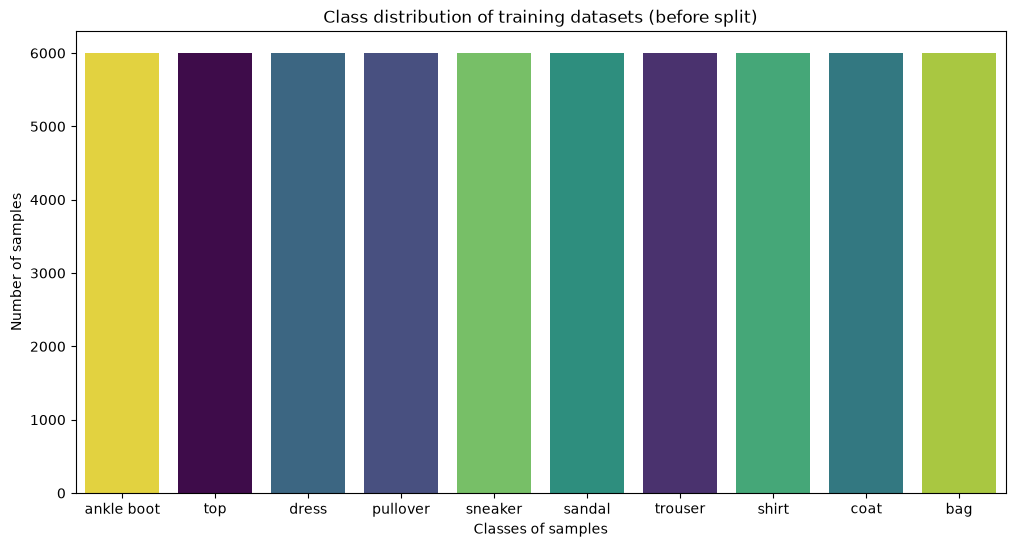

In [4]:
labels = raw_training_data.targets.numpy()
label_as_name = [label_names[label] for label in labels]

plt.figure(figsize=(12,6))
sns.countplot(x=label_as_name, hue=labels, palette="viridis", legend=False)
plt.title("Class distribution of training datasets (before split)")
plt.xlabel("Classes of samples")
plt.ylabel("Number of samples")
plt.show()

The dataset is perfectly balanced since each class has the same amount of samples - 6000 samples per class across all 10 classes. This means that there is no imbalance issue, which results as no resampling or assigning weight loss for classes are required. Moreover, the standard evaluation metrics like accuracy remain reliable. 

In [5]:
print(f"Training data's length: {len(raw_training_data)}")

img_smpl, label_smpl = raw_training_data[0]
img_tensor = v2.functional.pil_to_tensor(img_smpl)

print(f"Dimension of an image: {img_tensor.shape} - (C, H, W)") 
print(f"Value range of pixel: {img_tensor.min()} - {img_tensor.max()}")
print(f"Type of pixel: {img_tensor.dtype}")


Training data's length: 60000
Dimension of an image: torch.Size([1, 28, 28]) - (C, H, W)
Value range of pixel: 0 - 255
Type of pixel: torch.uint8


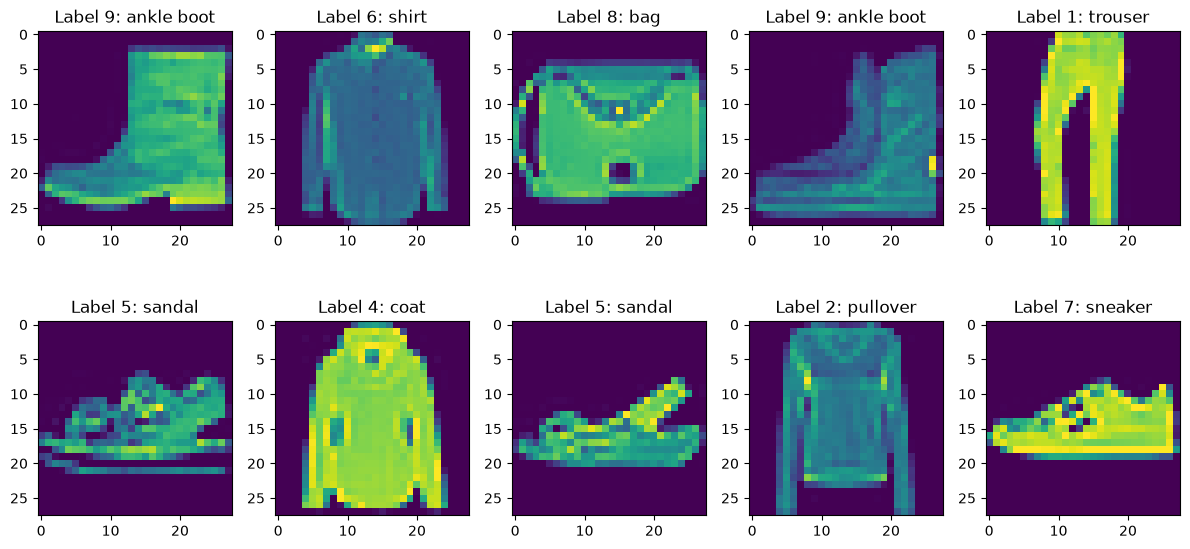

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    idx = torch.randint(0, len(raw_training_data), (1,)).item()
    img, label = raw_training_data[idx]
    
    ax.imshow(img)
    ax.set_title(f"Label {label}: {label_names[label]}")

plt.tight_layout()
plt.show()

# 2. Data pipeline & preprocessing
## 2.1. Preprocessing data 
- Construct preprocessing pipeline 


In [7]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])
full_training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True, 
    transform=transform
)

## 2.2. Data splitting 

In [8]:
train_data, val_data = random_split(full_training_data, [50000 , 10000], generator=torch.Generator().manual_seed(42))

## 2.3. Dataloader configuration

In [9]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader= DataLoader(test_data, batch_size=64, shuffle=False)

# 3. Training & Validation framework

In [10]:
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

In [20]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad(set_to_none=True)
        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        
        # Total loss
        running_loss += loss.item() * x_batch.size(0)
        
        # Total correct predictions
        _, pred = torch.max(y_pred, 1)
        total += y_batch.size(0)
        correct += (pred == y_batch).sum().item()
        
        if batch_idx % 200 == 0: 
            print(f"Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item(): .4f}")
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc
    
    
    
def evaluate(model, val_loader, loss_fn, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    total_y_true = []
    total_y_pred = []
    
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            
            # Total loss
            running_loss += loss.item() * x_batch.size(0)
            
            # Total correct predictions
            _, pred = torch.max(y_pred, 1)
            total += y_batch.size(0)
            correct += (pred == y_batch).sum().item()
            
            total_y_true.extend(y_batch.cpu().numpy())
            total_y_pred.extend(pred.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_macro_f1 = f1_score(total_y_true, total_y_pred, average='macro')
    return epoch_loss, epoch_acc, epoch_macro_f1
        

def train_loop(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10):
    print(f"Start training model {model.__class__.__name__}..." )
    
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}")
        print("-"*60)
        
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc, val_macro_f1 = evaluate(model, val_loader, loss_fn, device)
        
        print(f"Epoch [{epoch + 1}/{epochs}] | Training loss: {train_loss:.4f} - Training accuracy: {train_acc: .4f} |" 
              f"Validation Loss: {val_loss: .4f} - Validation accuracy: {val_acc: .4f} - Macro-F1: {val_macro_f1: .4f}")
        
    print("Training is done !")

# 4. Model architecture & preliminary results
## 4.1. Linear/ softmax classifier

In [21]:
class LinearSoftmaxClassifier(nn.Module):
    def __init__(self, input_dim=28*28, output_dim=10) -> None:
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        x = self.flatten(x)
        return self.linear(x)

## 4.2. Multilayer Perceptron (MLP)

In [22]:
class MLPClassifier(nn.Module): 
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim=10) -> None:
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.fc3 = nn.Linear(hidden_dim2, output_dim)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed()
model = LinearSoftmaxClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

train_loop(model, train_dataloader, val_dataloader, loss_fn, optimizer, device, epochs=10)

Start training model LinearSoftmaxClassifier...
Epoch 1
------------------------------------------------------------
Batch [0/782] Loss:  2.3136
Batch [200/782] Loss:  1.0709
Batch [400/782] Loss:  0.8271
Batch [600/782] Loss:  0.7640
Epoch [1/10] | Training loss: 1.0076 - Training accuracy:  0.6976 |Validation Loss:  0.7610 - Validation accuracy:  0.7544 - Macro-F1:  0.7433
Epoch 2
------------------------------------------------------------
Batch [0/782] Loss:  0.8581
Batch [200/782] Loss:  0.7405
Batch [400/782] Loss:  0.7448
Batch [600/782] Loss:  0.5821
Epoch [2/10] | Training loss: 0.6924 - Training accuracy:  0.7823 |Validation Loss:  0.6621 - Validation accuracy:  0.7877 - Macro-F1:  0.7857
Epoch 3
------------------------------------------------------------
Batch [0/782] Loss:  0.6460
Batch [200/782] Loss:  0.4968
Batch [400/782] Loss:  0.5770
Batch [600/782] Loss:  0.7809
Epoch [3/10] | Training loss: 0.6229 - Training accuracy:  0.8016 |Validation Loss:  0.6157 - Validation 